##**Entrega Final - Aprendizaje por Refuerzo**

### Aplicación del aprendizaje por refuerzo para la automatización de la solución de un laberinto usando un Agente Q-Learning

Omar Diaz / Diego Burbano

In [81]:
from google.colab import drive
from google.colab import files
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import collections
import random
import pickle
import io
from matplotlib import animation
from IPython.display import HTML
import time
import numpy as np


In [55]:
def cargar_archivo_txt():
  print("\n--- CARGA DE LABERINTO ---")
  print("Sube el archivo .txt con la configuración del laberinto:")
  uploaded = files.upload()
  if not uploaded:
        print("Operación cancelada: No se subió ningún archivo.")
        return None, None, None
  ruta_archivo = next(iter(uploaded))
  return ruta_archivo

In [56]:
def cargar_configuracion_laberinto():
  ruta_archivo = cargar_archivo_txt()
  paredes = set()
  with open(ruta_archivo, 'r') as f:
        lineas = f.readlines()

  # Leer dimensiones (N=8, M=7)
  n, m = map(int, lineas[0].strip().split())
  # Leer número de paredes
  k = int(lineas[1].strip())

  for i in range(2, 2 + k):
    coords = list(map(int, lineas[i].strip().split()))
    nodo_inicio = (coords[0], coords[1])
    nodo_fin = (coords[2], coords[3])
    paredes.add((nodo_inicio, nodo_fin))

  print(f"Número de paredes cargadas (incluyendo bordes): {len(paredes)}")
  return n, m, paredes



## **Definición del MDP**

In [57]:
# Definición de la clase principal del ambiente MDP
class Gridworld:
    def __init__(self, n_rows, n_cols, walls, initial_state=(6, 0), goal_state=(1, 6), goal_reward=100.0, step_reward=-1.0):
        self.nrows = n_rows
        self.ncols = n_cols
        self.walls = walls
        self.initial_state = initial_state
        self.state = self.initial_state
        self.step_reward = step_reward
        if goal_state is None:
            self.goal_state = (n_rows-1, n_cols-1)
        else:
            self.goal_state = goal_state

        # Inicializamos la grid con la recompensa por paso (step_reward)
        self.grid = [[self.step_reward for _ in range(self.ncols)] for _ in range(self.nrows)]
        # Asignar recompensa a la meta
        self.grid[self.goal_state[0]][self.goal_state[1]] = goal_reward


    def hay_pared(self, estado_a: tuple[int,int], estado_b: tuple[int,int], paredes_vertices=None) -> bool:
      if paredes_vertices is None:
        paredes_vertices = self.walls

      i1, j1 = estado_a
      i2, j2 = estado_b

      # Movimiento horizontal (izquierda / derecha)
      if i1 == i2 and abs(j1 - j2) == 1:
        j_max = max(j1, j2)
        # La pared vertical está en el límite derecho de la celda de origen/destino
        pared_vertical = ((i1, j_max), (i1 + 1, j_max))
        return pared_vertical in paredes_vertices

      # Movimiento vertical (arriba / abajo)
      if j1 == j2 and abs(i1 - i2) == 1:
        i_max = max(i1, i2)
        # La pared horizontal está en el límite inferior de la celda de origen/destino
        pared_horizontal = ((i_max, j1), (i_max, j1 + 1))
        return pared_horizontal in paredes_vertices
      return False


    def get_states(self) -> list[list[int]]:
        return self.grid

    def get_current_state(self) -> tuple[int, int]:
        return self.state

    def state_value(self, state:tuple[int, int]) -> float:
        return self.grid[state[0]][state[1]]

    def get_possible_actions(self, state:tuple[int,int]) -> list[str]:
        actions = ['up', 'right', 'down', 'left']
        i, j = state
        possible_ops = []
        if state == self.goal_state:
            possible_ops = ['exit']
            return possible_ops

        for action in actions:
            ni, nj = i, j

            # Calcular el estado siguiente potencial (ni, nj)
            if action == 'up': ni -= 1
            elif action == 'down': ni += 1
            elif action == 'left': nj -= 1
            elif action == 'right': nj += 1

            # Validar Límites (ni, nj debe estar dentro de la cuadrícula)
            is_inside_grid = 0 <= ni < self.nrows and 0 <= nj < self.ncols

            # Validar Paredes (incluso si el movimiento va al borde exterior, como 8 o 7)
            is_blocked_by_wall = self.hay_pared((i, j), (ni, nj), self.walls)

            # Un movimiento es posible solo si NO hay pared Y el estado siguiente está dentro de la cuadrícula.
            # Si el movimiento choca contra una pared del borde (ej. de (7,0) a (8,0)),
            # la condición hay_pared será True, bloqueando el movimiento antes de que verifique límites.
            if is_inside_grid and not is_blocked_by_wall:
                possible_ops.append(action)

        return possible_ops

    def do_action(self, action:str) -> tuple[float, tuple[int,int]]:
        valid_action = ""
        i, j = self.state
        ni, nj = i, j

        # Calcular el estado siguiente potencial (ni, nj)
        if action == 'up': ni -= 1
        elif action == 'down': ni += 1
        elif action == 'left': nj -= 1
        elif action == 'right': nj += 1

        # Chequeo de Paredes (internas y las definidas en el borde como (8, 7))
        move_is_blocked_by_wall = self.hay_pared((i, j), (ni, nj))

        # Chequeo de Límites (asegura que ni y nj están dentro de [0, 7] y [0, 6])
        valid_move_inside_grid = 0 <= ni < self.nrows and 0 <= nj < self.ncols

        # El movimiento se realiza SÍ Y SÓLO SÍ NO está bloqueado por pared Y está dentro de la cuadrícula
        if not move_is_blocked_by_wall and valid_move_inside_grid:
            valid_action = "Valida"
            self.state = (ni, nj)
            if self.state == self.goal_state:
                reward = None
                valid_action = "Finalizado"
        else:
            # Si choca contra pared o límite, se queda en el mismo sitio
            self.state = (i, j)

        # Recompensa basada en el estado final (new_state)
        condicion = ["Valida", "Finalizado"]
        if valid_action in condicion:
            reward = self.grid[self.state[0]][self.state[1]]
        else:
            valid_action = "Invalido"
            reward = -2.0

        return reward, self.state

    def reset(self):
        self.state = self.initial_state

    def is_terminal(self, state:tuple[int,int]=None) -> bool:
        if state is None:
            state = self.state
        is_goal = state == self.goal_state
        return is_goal

## **Carga del ambiente del Laberinto**

In [58]:
# Llamado del Ambiente laberinto usando la clase Gridworld
n, m, paredes = cargar_configuracion_laberinto()
ESTADO_INICIAL = (6, 0)
ESTADO_META = (1, 6)
NUM_EPISODES = 2000
gridworld = Gridworld(n_rows=n,
                n_cols=m,
                walls=paredes,
                initial_state=ESTADO_INICIAL,
                goal_state=ESTADO_META,
                goal_reward=100.0,
                step_reward=-1.0)


--- CARGA DE LABERINTO ---
Sube el archivo .txt con la configuración del laberinto:


Saving laberinto.txt to laberinto (2).txt
Número de paredes cargadas (incluyendo bordes): 65


In [59]:
gridworld.get_possible_actions((1,6))

['exit']

In [60]:
gridworld.get_states()

[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
 [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, 100.0],
 [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
 [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
 [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
 [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
 [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
 [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0]]

In [61]:
gridworld.hay_pared((0,6), (1,6), gridworld.walls)

False

In [62]:
gridworld.state = (0,6)

In [63]:
gridworld.do_action('down')

(100.0, (1, 6))

In [64]:
gridworld.reset()

In [65]:
gridworld.get_current_state()

(6, 0)

## **Definición de la clase del Agente**

In [140]:
#Agente de Q-learning
class QLearning:
    def __init__(self, env, epsilon=0.9, gamma=0.9, alpha=0.5):
        self.env = env
        self.epsilon = epsilon
        self.gamma = gamma
        self.alpha = alpha
        self.qtable ={}
        self.resultados = []
        self.exec_time = []

    def get_value(self, state:tuple[int,int], action:str) -> float:
        return self.qtable.get((state, action), 0.0)

    def choose_action(self, state:tuple[int,int]) -> str:
        actions = self.env.get_possible_actions(state)
        if not actions:
            return None
        if random.random() < self.epsilon:
            return random.choice(actions)
        q_values = [self.get_value(state, a) for a in actions]
        max_q = max(q_values)
        best_actions = [a for a, q in zip(actions, q_values) if q == max_q]
        return random.choice(best_actions)

    def update_values(self, state:tuple[int,int], action:str, next_state:tuple[int,int], reward:int) -> None:
        q_sa = self.get_value(state, action)
        if self.env.is_terminal(next_state):
            max_q_next = 0.0
        else:
            possible_actions = self.env.get_possible_actions(next_state)
            if possible_actions:
                q_values_next = [self.get_value(next_state, a) for a in possible_actions]
                max_q_next = max(q_values_next)
            else:
                max_q_next = 0.0
        new_q = (1 - self.alpha) * q_sa + self.alpha * (reward + self.gamma * max_q_next)
        self.qtable[(state, action)] = new_q

    def best_action(self, state:tuple[int,int]) -> str:
        actions = self.env.get_possible_actions(state)
        if not actions:
            return ""
        if actions == ['exit']:
            return 'exit'
        q_values = [self.get_value(state, a) for a in actions]
        max_q = max(q_values)
        best_actions = [a for a, q in zip(actions, q_values) if q == max_q]
        return random.choice(best_actions)

    def step(self, action:str) -> tuple[tuple[int,int],int, bool, str]:
        initial_state = self.env.get_current_state()
        reward, next_state = self.env.do_action(action)
        status = self.env.is_terminal(next_state)
        info = f"Estado inicial: {initial_state} tomando la acción: {action} -> {next_state} (recompensa {reward})"
        return [next_state, reward, status, info]

    def run(self, episodes:int) -> dict[tuple[int,str],float]:
        for episode in range(episodes):
            start_time = time.time()
            self.env.reset()
            state = self.env.get_current_state()
            count_steps = 0
            while not self.env.is_terminal(state):
                action = self.choose_action(state)
                if action is None:
                    break
                next_state, reward, status, info = self.step(action)
                self.update_values(state, action, next_state, reward)
                state = next_state
                count_steps += 1
            end_time = time.time()
            self.resultados.append((episode, count_steps))
            self.exec_time.append(end_time - start_time)
            if episode % 100 == 0:
                if self.epsilon > 0.01:
                    self.epsilon *= 0.9
                    self.epsilon = max(self.epsilon, 0.01)
        return self.qtable

    def test_performance(self) -> tuple[dict, dict]:
        actions = {}
        values = {}
        for i in range(self.env.nrows):
            for j in range(self.env.ncols):
                    if not self.env.is_terminal((i,j)):
                        action = self.best_action((i,j))
                        actions[(i,j)] = action
                        values[(i,j)] = self.get_value((i,j), action)
        return actions, values

## **Entrenamiento del Agente**

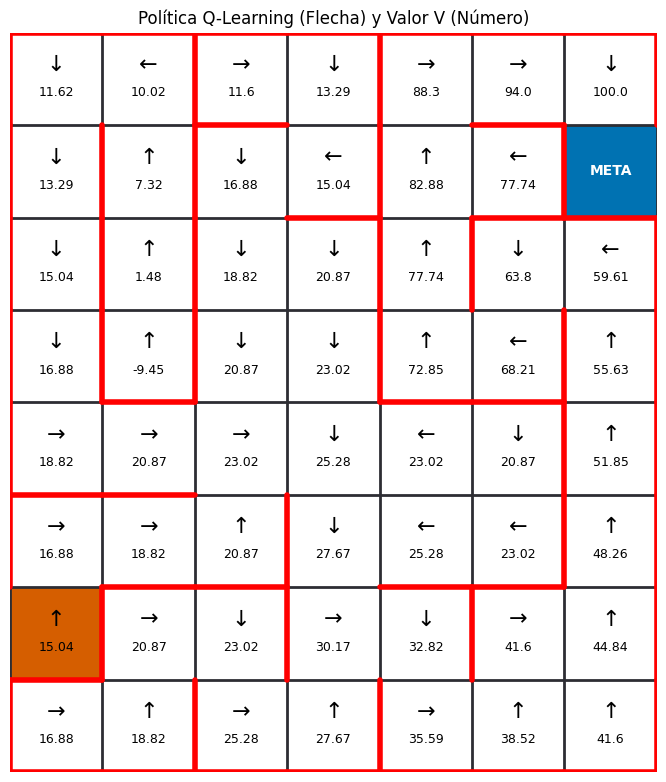

In [174]:
a = QLearning(gridworld, epsilon=0.95, gamma=0.95, alpha=0.3)
qtable = a.run(10000)
policy, values = a.test_performance()

def draw_action(action):
    """Convierte la acción de texto a un símbolo gráfico."""
    if action == 'left':
        return '←'
    if action == 'right':
        return '→'
    if action == 'up':
        return '↑'
    if action == 'down':
        return '↓'
    return 'X'

# Función Principal de Graficación

def plot_actions(env, actions, values):

    fig1 = plt.figure(figsize=(env.ncols * 1.2, env.nrows * 1.2))
    ax1 = fig1.add_subplot(111)

    for i in range(0, env.nrows + 1):
        ax1.axhline(i, linewidth=2, color="#2D2D33")
    for j in range(env.ncols + 1):
        ax1.axvline(j, linewidth=2, color="#2D2D33")

    for i in range(env.nrows):
        for j in range(env.ncols):
            current_state = (i, j)
            rect_y = i

            if current_state == env.goal_state:
                # Color AZUL para la meta (Referencia)
                ax1.add_patch(patches.Rectangle((j, rect_y), 1, 1, facecolor="#0072B2"))
                ax1.text(j + 0.5, rect_y + 0.5, "META", ha='center', va='center', fontweight='bold', color='white')
                continue

            elif current_state == env.initial_state:
                # Color ROJO para el inicio (Referencia)
                ax1.add_patch(patches.Rectangle((j, rect_y), 1, 1, facecolor="#D55E00"))


            elif env.grid[i][j] == -100:
                ax1.add_patch(patches.Rectangle((j, rect_y), 1, 1, facecolor="#6c7780"))
                ax1.text(j + 0.5, rect_y + 0.5, "-100", ha='center', va='center', color='white')
                continue


            if current_state in values:
                # Mostrar el valor Q (Valor del estado)
                value_text = str(round(values[current_state], 2))
                ax1.text(j + 0.5, rect_y + 0.65, value_text, ha='center', va='center', fontsize=9)

                # Mostrar la mejor acción (flecha)
                action_symbol = draw_action(actions[current_state])
                ax1.text(j + 0.5, rect_y + 0.35, action_symbol, ha='center', va='center', fontsize=16)


    for (i1, j1), (i2, j2) in env.walls:
        # Usamos las coordenadas i y j (filas/columnas) directamente para el trazado.
        plot_i1, plot_i2 = i1, i2
        plot_j1, plot_j2 = j1, j2

        if i1 == i2:  # Pared horizontal
            y_coord = i1
            x_start = min(j1, j2)
            x_end = max(j1, j2)

            ax1.plot([x_start, x_end], [y_coord, y_coord], color='red', linewidth=4, solid_capstyle='round')

        elif j1 == j2: # Pared vertical
            x_coord = j1
            y_start = min(i1, i2)
            y_end = max(i1, i2)

            ax1.plot([x_coord, x_coord], [y_start, y_end], color='red', linewidth=4, solid_capstyle='round')


    ax1.set_xlim(0, env.ncols)
    ax1.set_ylim(0, env.nrows)
    ax1.set_aspect('equal', adjustable='box')
    plt.xticks(range(env.ncols + 1))
    plt.yticks(range(env.nrows + 1))
    ax1.invert_yaxis()

    plt.axis("off")
    plt.title("Política Q-Learning (Flecha) y Valor V (Número)")
    plt.show()

plot_actions(gridworld, policy, values)

In [175]:
print(a.resultados)

[(0, 1885), (1, 489), (2, 319), (3, 649), (4, 1085), (5, 1383), (6, 97), (7, 419), (8, 185), (9, 239), (10, 695), (11, 525), (12, 431), (13, 141), (14, 155), (15, 281), (16, 393), (17, 255), (18, 87), (19, 427), (20, 375), (21, 245), (22, 131), (23, 257), (24, 285), (25, 411), (26, 349), (27, 359), (28, 235), (29, 107), (30, 213), (31, 193), (32, 139), (33, 121), (34, 601), (35, 101), (36, 165), (37, 155), (38, 289), (39, 129), (40, 107), (41, 247), (42, 109), (43, 107), (44, 195), (45, 287), (46, 67), (47, 109), (48, 119), (49, 89), (50, 115), (51, 209), (52, 157), (53, 165), (54, 241), (55, 71), (56, 279), (57, 161), (58, 197), (59, 145), (60, 289), (61, 221), (62, 141), (63, 155), (64, 323), (65, 389), (66, 361), (67, 609), (68, 135), (69, 287), (70, 163), (71, 241), (72, 151), (73, 119), (74, 225), (75, 167), (76, 97), (77, 133), (78, 383), (79, 105), (80, 537), (81, 127), (82, 331), (83, 251), (84, 195), (85, 201), (86, 125), (87, 121), (88, 637), (89, 69), (90, 177), (91, 143), (

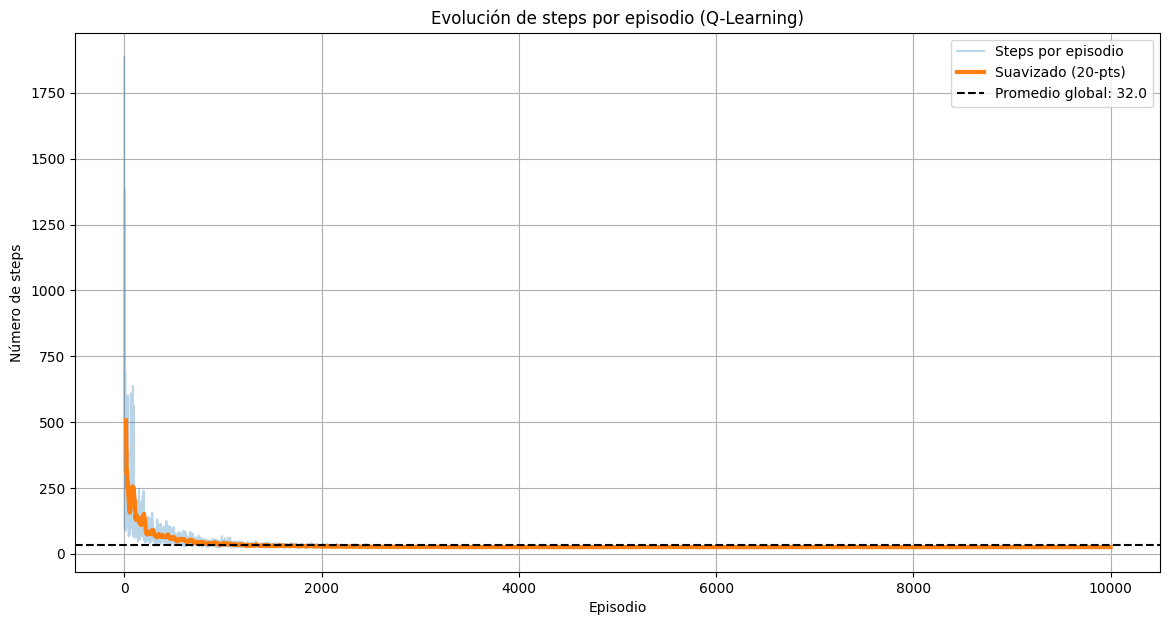

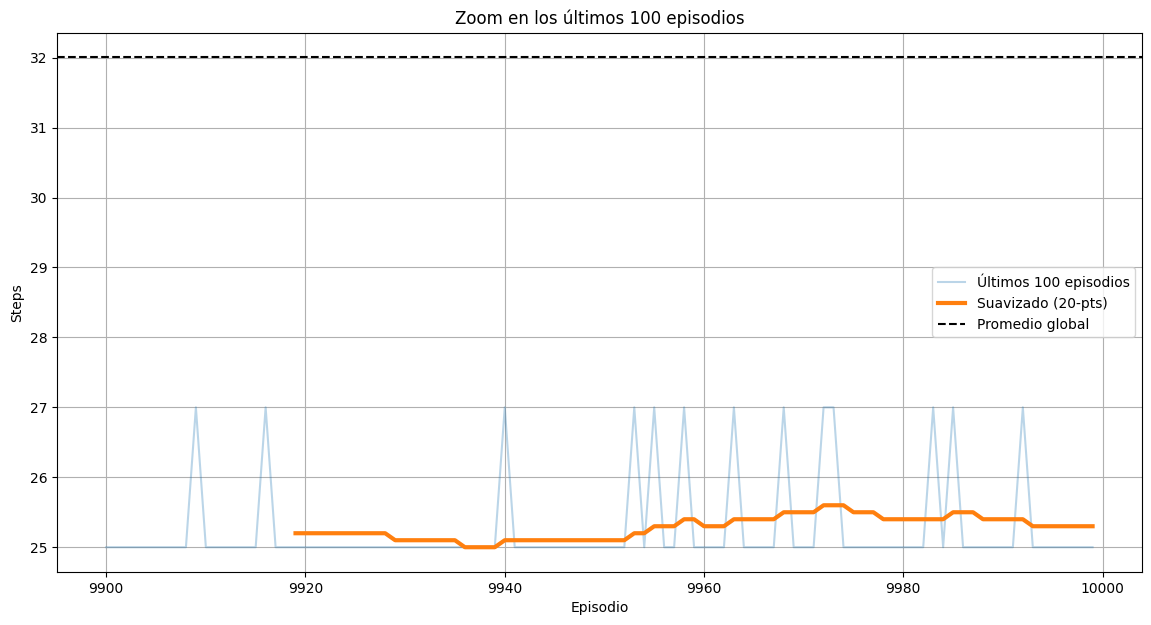

In [176]:
#Grafica de número de pasos (steps) por cada episodio ejecutado

resultados = a.resultados
episodios = np.array([x[0] for x in resultados])
steps = np.array([x[1] for x in resultados])

# Suavizado (Moving Average)
window = 20
if len(steps) >= window:
    suavizado = np.convolve(steps, np.ones(window)/window, mode='valid')
    episodios_suav = episodios[window-1:]
else:
    suavizado = steps
    episodios_suav = episodios

promedio_global = np.mean(steps)

plt.figure(figsize=(14,7))
plt.plot(episodios, steps, alpha=0.3, label="Steps por episodio")
plt.plot(episodios_suav, suavizado, linewidth=3, label=f"Suavizado ({window}-pts)")
plt.axhline(promedio_global, color="black", linestyle="--", label=f"Promedio global: {promedio_global:.1f}")

plt.xlabel("Episodio")
plt.ylabel("Número de steps")
plt.title("Evolución de steps por episodio (Q-Learning)")
plt.legend()
plt.grid(True)
plt.show()

# Gráfica de zoom en la etapa final
zoom = 100  # cantidad de episodios finales a mostrar
eps_zoom = episodios[-zoom:]
steps_zoom = steps[-zoom:]

if len(steps_zoom) >= window:
    suav_zoom = np.convolve(steps_zoom, np.ones(window)/window, mode='valid')
    eps_suav_zoom = eps_zoom[window-1:]
else:
    suav_zoom = steps_zoom
    eps_suav_zoom = eps_zoom

plt.figure(figsize=(14,7))
plt.plot(eps_zoom, steps_zoom, alpha=0.3, label=f"Últimos {zoom} episodios")
plt.plot(eps_suav_zoom, suav_zoom, linewidth=3, label=f"Suavizado ({window}-pts)")
plt.axhline(promedio_global, color="black", linestyle="--", label="Promedio global")

plt.xlabel("Episodio")
plt.ylabel("Steps")
plt.title(f"Zoom en los últimos {zoom} episodios")
plt.legend()
plt.grid(True)
plt.show()


In [180]:
len(resultados)

10000

In [181]:
len(np.array(a.exec_time[:len(resultados)]) * 1000)

10000

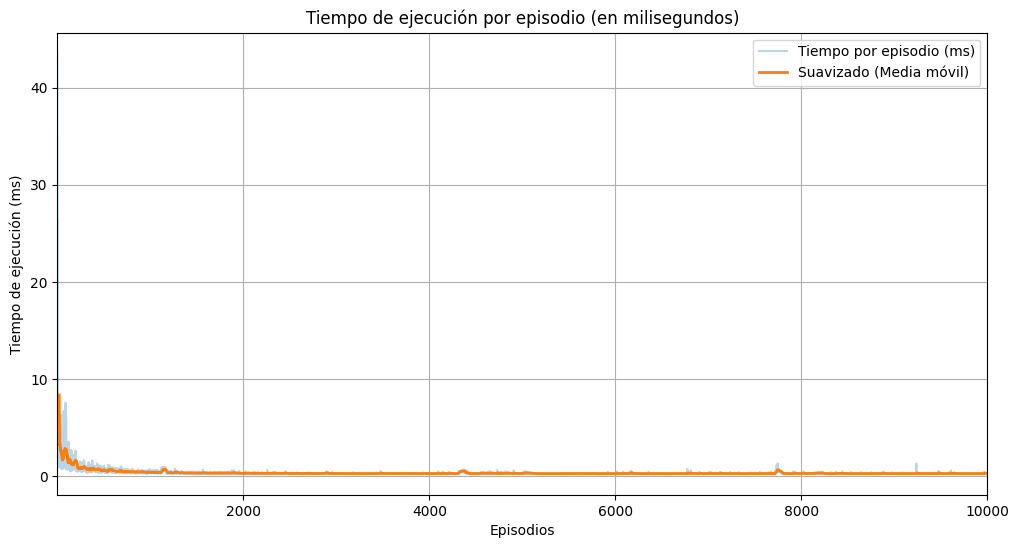

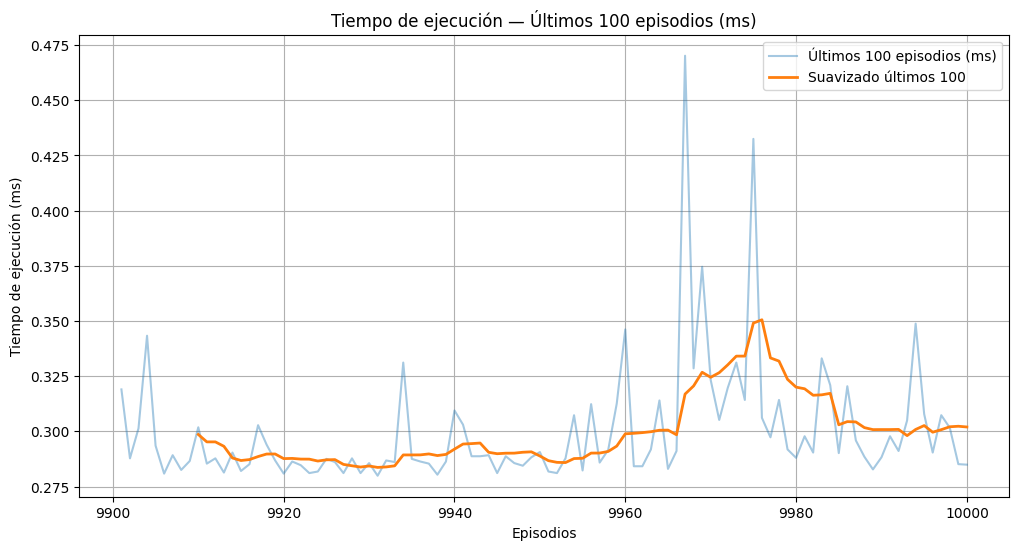

In [182]:
import matplotlib.pyplot as plt
import numpy as np

# --- Ajuste crítico ---
# Igualar el número de tiempos al número REAL de episodios
exec_time_ms = np.array(a.exec_time[:len(resultados)]) * 1000

episodes = np.arange(1, len(exec_time_ms) + 1)

# Suavizado media móvil
window = 20
smooth = np.convolve(exec_time_ms, np.ones(window)/window, mode='valid')
episodes_smooth = episodes[window-1:]

plt.figure(figsize=(12, 6))
plt.plot(episodes, exec_time_ms, alpha=0.3, label='Tiempo por episodio (ms)')
plt.plot(episodes_smooth, smooth, linewidth=2, label='Suavizado (Media móvil)')
plt.xlabel('Episodios')
plt.ylabel('Tiempo de ejecución (ms)')
plt.title('Tiempo de ejecución por episodio (en milisegundos)')
plt.legend()
plt.grid(True)
plt.xlim(1, len(exec_time_ms))  # EXACTO: eje X = 1000 episodios
plt.show()

last_n = 100
exec_last_ms = exec_time_ms[-last_n:]
episodes_last = episodes[-last_n:]

# Suavizado últimos 100
window_last = 10
smooth_last = np.convolve(exec_last_ms, np.ones(window_last)/window_last, mode='valid')
episodes_last_smooth = episodes_last[window_last-1:]

plt.figure(figsize=(12, 6))
plt.plot(episodes_last, exec_last_ms, alpha=0.4, label='Últimos 100 episodios (ms)')
plt.plot(episodes_last_smooth, smooth_last, linewidth=2, label='Suavizado últimos 100')
plt.xlabel('Episodios')
plt.ylabel('Tiempo de ejecución (ms)')
plt.title('Tiempo de ejecución — Últimos 100 episodios (ms)')
plt.legend()
plt.grid(True)
plt.show()


In [157]:
gridworld.get_current_state()

(1, 6)

In [105]:
def guardar_modelo(agent, default_nombre_archivo="qtable_laberinto_final.pkl"):
    """
    Guarda la Q-Table del agente en un archivo binario (.pkl) y la descarga
    al ordenador del usuario de forma interactiva en Google Colab.

    Args:
        agent: La instancia del agente QLearning que contiene la qtable.
        default_nombre_archivo: Nombre de archivo sugerido por defecto.
    """
    COLAB_ENV = True
    print("\n--- GUARDAR MODELO (Q-TABLE) ---")

    nombre_archivo = input(f"Ingrese el nombre de archivo para guardar (ej: mi_agente.pkl). Deje vacío para usar '{default_nombre_archivo}': ")

    # Usar el nombre por defecto si la entrada está vacía o asegurar la extensión
    if not nombre_archivo.strip():
        nombre_archivo = default_nombre_archivo
    elif not nombre_archivo.lower().endswith('.pkl'):
        nombre_archivo += '.pkl'

    # Guardar el archivo localmente en el entorno Colab
    try:
        with open(nombre_archivo, "wb") as f:
            pickle.dump(agent.qtable, f)

        print(f"Q-Table guardada localmente en '{nombre_archivo}'.")

        # Descargar el archivo al equipo local
        if COLAB_ENV:
          print("   Iniciando descarga en su navegador...")
          files.download('mi_mejor_modelo.pkl')
        else:
          print(f"   Guardado localmente. Ejecute esto en Google Colab para la descarga directa.")

    except Exception as e:
        print(f"Error al guardar o descargar el modelo: {e}")

In [106]:
guardar_modelo(a, "mi_mejor_modelo.pkl")


--- GUARDAR MODELO (Q-TABLE) ---
Ingrese el nombre de archivo para guardar (ej: mi_agente.pkl). Deje vacío para usar 'mi_mejor_modelo.pkl': 
Q-Table guardada localmente en 'mi_mejor_modelo.pkl'.
   Iniciando descarga en su navegador...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [107]:
def cargar_modelo():
    """
    Pide al usuario que suba un archivo .pkl y carga la Q-Table.

    Retorna la Q-Table (diccionario) cargada o None si falla.
    """
    print("\n--- CARGA DE MODELO (Q-TABLE) ---")
    print("Por favor, selecciona el archivo .pkl de tu modelo Q-Learning:")

    # 1. Widget de subida
    uploaded = files.upload()

    if not uploaded:
        print("Operación cancelada: No se subió ningún archivo.")
        return None

    # 2. Obtener el nombre y el contenido binario del archivo subido
    nombre_archivo = next(iter(uploaded))

    # El contenido binario está en uploaded[nombre_archivo]
    contenido_binario = uploaded[nombre_archivo]

    # 3. Cargar la Q-Table usando pickle desde el buffer de memoria
    try:
        # Usamos io.BytesIO para tratar el contenido subido como un archivo
        qtable_cargada = pickle.load(io.BytesIO(contenido_binario))

        print(f"Modelo '{nombre_archivo}' cargado exitosamente.")
        print(f"   Tamaño de la tabla: {len(qtable_cargada)} estados-acción.")

        return qtable_cargada

    except pickle.UnpicklingError:
        print(f"Error: El archivo '{nombre_archivo}' no es un objeto Python válido (¿Es realmente un .pkl?).")
        return None
    except Exception as e:
        print(f"Error general al cargar el modelo: {e}")
        return None


--- CARGA DE MODELO (Q-TABLE) ---
Por favor, selecciona el archivo .pkl de tu modelo Q-Learning:


Saving mi_mejor_modelo.pkl to mi_mejor_modelo (2).pkl
Modelo 'mi_mejor_modelo (2).pkl' cargado exitosamente.
   Tamaño de la tabla: 119 estados-acción.

--- Iniciando Inferencia (Simulación) ---


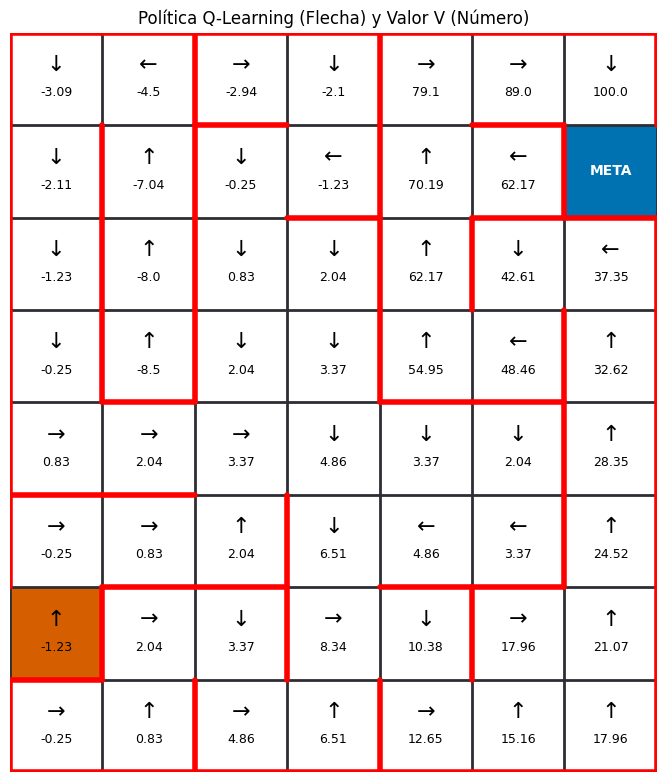

In [108]:
# Cargar la configuración del laberinto
#n, m, paredes = cargar_configuracion_laberinto()

# Inicializar el Ambiente
gridworld_inferencia = Gridworld(n_rows=n, n_cols=m, walls=paredes,
                                 initial_state=(6, 0), goal_state=(1, 6))

# Cargar la Q-Table
qtable_recuperada = cargar_modelo()

if qtable_recuperada:
    # Inicializar el Agente en MODO INFERENCIA
    # epsilon=0.0 -> Para que no explore (solo use lo aprendido)
    # alpha=0.0   -> Para que no modifique la tabla (congelado)
    agente_inferencia = QLearning(gridworld_inferencia, epsilon=0.0, gamma=0.9, alpha=0.0)

    # ALMACENAR LA TABLA APRENDIDA
    agente_inferencia.qtable = qtable_recuperada

    print("\n--- Iniciando Inferencia (Simulación) ---")

    # Ejecutar y Graficar

    policy, values = agente_inferencia.test_performance()
    plot_actions(gridworld_inferencia, policy, values)

In [109]:
def obtener_ruta_optima(env, agent, max_steps=100):
    """
    Simula una corrida del agente y retorna la lista de coordenadas visitadas.
    """
    env.reset()
    current_state = env.get_current_state()
    path = [current_state]

    for _ in range(max_steps):
        if env.is_terminal(current_state):
            break

        # Usamos best_action (Greedy) para inferencia
        action = agent.best_action(current_state)

        if not action:
            break

        # Ejecutar movimiento (sin aprender)
        _, next_state = env.do_action(action)

        path.append(next_state)
        current_state = next_state

    return path

def animar_solucion(env, path):
    """
    Crea una animación HTML5 del agente recorriendo el path.
    """
    # Configurar la figura
    fig, ax = plt.subplots(figsize=(env.ncols * 0.8, env.nrows * 0.8))

    # Dibujar el Laberinto Estático
    for i in range(env.nrows + 1):
        ax.axhline(i, linewidth=2, color="#2D2D33")
    for j in range(env.ncols + 1):
        ax.axvline(j, linewidth=2, color="#2D2D33")

    # Dibujar Meta, Inicio
    for i in range(env.nrows):
        for j in range(env.ncols):
            rect_y = i
            if (i, j) == env.goal_state:
                ax.add_patch(patches.Rectangle((j, rect_y), 1, 1, facecolor="#0072B2")) # Azul
            elif (i, j) == env.initial_state:
                ax.add_patch(patches.Rectangle((j, rect_y), 1, 1, facecolor="#D55E00")) # Rojo
            elif env.grid[i][j] == -100:
                ax.add_patch(patches.Rectangle((j, rect_y), 1, 1, facecolor="#6c7780")) # Gris

    # Dibujar Paredes
    for (i1, j1), (i2, j2) in env.walls:
        plot_i1, plot_i2 = i1, i2
        plot_j1, plot_j2 = j1, j2
        if i1 == i2: # Horizontal
            ax.plot([min(j1, j2), max(j1, j2)], [i1, i1], color='red', linewidth=4, solid_capstyle='round')
        elif j1 == j2: # Vertical
            ax.plot([j1, j1], [min(i1, i2), max(i1, i2)], color='red', linewidth=4, solid_capstyle='round')

    # Configurar el Agente (Círculo morado)
    # Inicializamos el agente fuera de la vista o en el inicio
    start_y = path[0][0] + 0.5
    start_x = path[0][1] + 0.5
    agent_circle = plt.Circle((start_x, start_y), 0.3, color='purple', zorder=10)
    ax.add_patch(agent_circle)

    # Configuración de ejes
    ax.set_xlim(0, env.ncols)
    ax.set_ylim(0, env.nrows)
    ax.set_aspect('equal')
    plt.xticks([])
    plt.yticks([])
    ax.invert_yaxis()
    plt.title("Simulación del Agente (Q-Learning)")

    # Función de actualización para la animación
    def update(frame):
        if frame < len(path):
            state = path[frame]
            agent_circle.center = (state[1] + 0.5, state[0] + 0.5)
        return agent_circle,

    # Crear animación
    anim = animation.FuncAnimation(fig, update, frames=len(path)+10, interval=200, blit=True)

    # Cerrar la figura estática para que no se muestre doble
    plt.close()

    return HTML(anim.to_jshtml())

In [110]:
# Calcular la ruta que tomará el agente
ruta_final = obtener_ruta_optima(gridworld_inferencia, agente_inferencia)
print(f"Ruta calculada: {len(ruta_final)} pasos.")

# Generar animación
# Esto mostrará un reproductor de video interactivo en el notebook
animar_solucion(gridworld_inferencia, ruta_final)

Ruta calculada: 26 pasos.
